# 🧠 Modélisation Couche 1 — deux familles de cibles

Le dataset contient **9 variables cibles**, mais elles ne sont **pas de même nature**.
Les mélanger dans un seul tableau de R² donne des scores incohérents (certains à 1.0,
d'autres très négatifs). On les sépare donc proprement :

| Famille | Cibles | Nature | Ce qu'on en fait |
|---|---|---|---|
| **① Mesurées** | `yield`, `water_stress`, `soil_degradation`, `thermal_anomaly` | issues de **datasets réels** (FAO, World Bank) | **Modèle ML** (on les *prédit*) |
| **② Dérivées** | `npp`, `fauna_density`, `parasite_vsi`, `flood_risk`, `erosion_prob` | **calculées par des formules** dans `build_dataset.py` | **Calcul direct** (on ne les prédit pas) |

> **Évaluation par PAYS** (`GroupShuffleSplit` sur `ISO`) : les pays de test ne sont
> jamais vus à l'entraînement. C'est la seule façon d'avoir un R² honnête ici : les
> features physiques sont **constantes par pays**, donc un split temporel laisse le
> modèle mémoriser chaque pays → faux R²=1.0.

In [1]:
# ── IMPORTATIONS & CONFIGURATION ──────────────────────────────────────────
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, f1_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)
print("✅ Importations terminées.")

✅ Importations terminées.


## 📦 1. Chargement & préparation

In [2]:
# ── CHARGEMENT ─────────────────────────────────────────────────────────────
df = pd.read_csv("data/cleaned/dataset_final_modelisation.csv")
print(f"Shape brut : {df.shape}")

# 'ISO' = groupe du split par pays + clé de jointure entre couches -> obligatoire.
df = df.dropna(subset=['Rendement_kgha', 'ISO']).copy()
print(f"Après filtrage (rendement + ISO) : {len(df):,} lignes | {df['ISO'].nunique()} pays")

Shape brut : (153374, 180)
Après filtrage (rendement + ISO) : 152,898 lignes | 186 pays


## 🛠️ 2. Définition des cibles et des features

`SPLITTER` découpe **par pays**. `target_features_map` exclut, pour chaque cible,
les variables qui apparaissent directement dans sa formule (anti-fuite).

In [3]:
SPLITTER = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

# ── Famille ① : cibles MESURÉES (vraies données) -> ML ────────────────────
TARGETS_MESUREES = {
    'target_yield':            {'type': 'regression',     'nom': 'Rendement agricole',  'source': 'FAO (kg/ha)'},
    'target_water_stress':     {'type': 'regression',     'nom': 'Stress hydrique',     'source': 'World Bank (% prélèvement)'},
    'target_soil_degradation': {'type': 'regression',     'nom': 'Dégradation du sol',  'source': 'FAO (bilan nutritif)'},
    'target_thermal_anomaly':  {'type': 'regression',     'nom': 'Anomalie thermique',  'source': 'T° annuelle − climatologie'},
}

# ── Famille ② : cibles DÉRIVÉES (formules de build_dataset.py) -> calcul ──
TARGETS_DERIVEES = {
    'target_npp':           {'type': 'regression',     'nom': 'NPP (biomes)',        'formule': 'Miami model : min(f(T), g(P))'},
    'target_fauna_density': {'type': 'regression',     'nom': 'Densité de faune',    'formule': 'fauna = 0.05 × NPP'},
    'target_parasite_vsi':  {'type': 'regression',     'nom': 'Indice parasitaire',  'formule': 'VSI = 10·exp(-(T-26)²/50)·(1-exp(-P/800))'},
    'target_flood_risk':    {'type': 'classification', 'nom': "Risque d'inondation",  'formule': '(elevation ≤ 50) & (dist_eau ≤ 5)'},
    'target_erosion_prob':  {'type': 'regression',     'nom': "Probabilité d'érosion", 'formule': '100·exp(-dist_côte/5)·(marée/5) + 50·exp(-dist_riv/1)'},
}

# Features par cible (proxies, sans les variables de formule)
energy_dummies = [c for c in df.columns if c.startswith('closest_energy_type_')]
target_features_map = {
    'target_yield': ['Annee','Produit_TargetEnc','ISO_TargetEnc','Engrais_kgha','Pesticides_kgha','Bilan_sols_kgha','log_Engrais_kgha','log_Pesticides_kgha','Temperature_C','Temperature_C_sq','Precipitations_mm','Precipitations_mm_sq','Engrais_Temp_interaction','Superficie_pays_ha','Superficie_terres_ha','Terres_agricoles_ha','Terres_culture_ha','Terres_arables_ha','Irrigation_equipee_ha','Irrigation_reelle_ha','Bio_ha','Part_terres_agricoles','Part_terres_arables','Part_irriguee','Part_bio'],
    'target_water_stress': ['temp_mean','precip_mean','precip_seasonality','dist_to_river_km','dist_to_lake_km','dist_to_coast_km','dist_to_freshwater_km','groundwater_depth_m','GDP_pc','HDI','Superficie_pays_ha','Terres_agricoles_ha'],
    'target_soil_degradation': ['clay_pct','silt_pct','sand_pct','soil_pH','organic_carbon_pct','Engrais_kgha','Pesticides_kgha','log_Engrais_kgha','Part_terres_agricoles','Part_terres_arables','Part_irriguee'],
    'target_thermal_anomaly': ['temp_mean','temp_max','temp_min','solar_radiation_mean','dist_to_energy_source_km'] + energy_dummies,
    'target_npp': ['latitude','elevation','solar_radiation_mean','vapor_pressure_mean','precip_seasonality','wind_speed_mean','temp_max','temp_min','dist_to_coast_km'],
    'target_fauna_density': ['temp_mean','precip_mean','elevation','solar_radiation_mean','estimated_wood_density_g_cm3','vapor_pressure_mean','precip_seasonality','dist_to_freshwater_km'],
    'target_parasite_vsi': ['latitude','elevation','vapor_pressure_mean','solar_radiation_mean','temp_max','temp_min','precip_seasonality','wind_speed_mean','dist_to_freshwater_km'],
    'target_flood_risk': ['slope_pct','roughness_m','dist_to_river_km','dist_to_lake_km','dist_to_coast_km','groundwater_depth_m','precip_mean','precip_seasonality','clay_pct','sand_pct'],
    'target_erosion_prob': ['elevation','slope_pct','roughness_m','dist_to_lake_km','dist_to_freshwater_km','precip_mean','precip_seasonality','clay_pct','sand_pct','wind_speed_mean'],
}

def split_par_pays(col):
    d = df.dropna(subset=[col]).copy()
    tr, te = next(SPLITTER.split(d, groups=d['ISO']))
    return d.iloc[tr].copy(), d.iloc[te].copy()

def make_preprocessor():
    return Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

print(f"① Mesurées (ML) : {list(TARGETS_MESUREES)}")
print(f"② Dérivées (calc): {list(TARGETS_DERIVEES)}")

① Mesurées (ML) : ['target_yield', 'target_water_stress', 'target_soil_degradation', 'target_thermal_anomaly']
② Dérivées (calc): ['target_npp', 'target_fauna_density', 'target_parasite_vsi', 'target_flood_risk', 'target_erosion_prob']


## ① Famille MESURÉE — entraînement des modèles ML

Pour chaque cible mesurée : split par pays, Ridge / Random Forest / XGBoost,
on garde le meilleur (R² test). Pour `yield`, le *target encoding* `Produit`/`ISO`
est recalculé **sur le train seul** (un pays de test inconnu reçoit la moyenne globale).

In [4]:
ml_summary = []
test_idx_ml = {}

for col, info in TARGETS_MESUREES.items():
    print(f"\n{'='*64}\n🎯 {info['nom']} ({col}) — {info['source']}\n{'='*64}")
    df_tr, df_te = split_par_pays(col)

    if col == 'target_yield':  # target encoding recalculé sur le train uniquement
        gmean = df_tr['log1p_Rendement'].mean()
        yield_enc = {'gmean': gmean, 'maps': {}}   # mémorisé pour le diagnostic
        for src, dst in [('Produit', 'Produit_TargetEnc'), ('ISO', 'ISO_TargetEnc')]:
            means = df_tr.groupby(src)['log1p_Rendement'].mean()
            yield_enc['maps'][(src, dst)] = means
            df_tr[dst] = df_tr[src].map(means).fillna(gmean)
            df_te[dst] = df_te[src].map(means).fillna(gmean)

    feats = [c for c in target_features_map[col] if c in df_tr.columns]
    Xtr, ytr = df_tr[feats], df_tr[col]
    Xte, yte = df_te[feats], df_te[col]
    test_idx_ml[col] = df_te.index
    print(f"   Pays train {df_tr['ISO'].nunique()} | test {df_te['ISO'].nunique()} (disjoints) | "
          f"lignes {len(Xtr):,}/{len(Xte):,}")

    pre = make_preprocessor()
    models = {
        'Ridge': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1),
        'XGBoost': XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
    }
    best = (-np.inf, None, None)
    for name, m in models.items():
        pipe = Pipeline([('pre', pre), ('model', m)])
        pipe.fit(Xtr, ytr)
        r2 = r2_score(yte, pipe.predict(Xte))
        print(f"   [{name:13s}] R² = {r2:.4f}")
        if r2 > best[0]:
            best = (r2, name, pipe)
    joblib.dump(best[2], f"models/best_{col}.joblib")
    print(f"   🏆 {best[1]} → R² = {best[0]:.4f}")
    ml_summary.append({'Cible': info['nom'], 'Nom technique': col, 'Source': info['source'],
                       'Meilleur modèle': best[1], 'R² (pays inconnus)': round(best[0], 3)})


🎯 Rendement agricole (target_yield) — FAO (kg/ha)


   Pays train 139 | test 47 (disjoints) | lignes 112,006/40,892


   [Ridge        ] R² = 0.6825


   [Random Forest] R² = 0.6660


   [XGBoost      ] R² = 0.6910
   🏆 XGBoost → R² = 0.6910

🎯 Stress hydrique (target_water_stress) — World Bank (% prélèvement)


...

   [XGBoost      ] R² = -1.4470
   🏆 Ridge → R² = -0.0943

🎯 Dégradation du sol (target_soil_degradation) — FAO (bilan nutritif)
   Pays train 87 | test 29 (disjoints) | lignes 44,733/13,892
   [Ridge        ] R² = 0.5342


   [Random Forest] R² = 0.4941
   [XGBoost      ] R² = 0.5128
   🏆 Ridge → R² = 0.5342

🎯 Anomalie thermique (target_thermal_anomaly) — T° annuelle − climatologie


   Pays train 137 | test 46 (disjoints) | lignes 104,392/35,511
   [Ridge        ] R² = 0.3170


   [Random Forest] R² = 0.3276


   [XGBoost      ] R² = -0.0768
   🏆 Random Forest → R² = 0.3276


### 📊 Résultats ML (famille mesurée)

In [5]:
from IPython.display import display
ml_df = pd.DataFrame(ml_summary)

def couleur(v):
    if isinstance(v, (int, float)):
        if v >= 0.6:  return 'background-color:#c6efce'   # vert
        if v >= 0.3:  return 'background-color:#ffeb9c'   # jaune
        return 'background-color:#ffc7ce'                 # rouge
    return ''

display(ml_df.style.map(couleur, subset=['R² (pays inconnus)']).format({'R² (pays inconnus)':'{:.3f}'}).hide(axis='index'))
print("Lecture : yield se prédit bien ; water_stress/thermal généralisent mal entre pays")
print("(facteurs socio-éco non capturés) — c'est honnête, pas un bug.")

Cible,Nom technique,Source,Meilleur modèle,R² (pays inconnus)
Rendement agricole,target_yield,FAO (kg/ha),XGBoost,0.691
Stress hydrique,target_water_stress,World Bank (% prélèvement),Ridge,-0.094
Dégradation du sol,target_soil_degradation,FAO (bilan nutritif),Ridge,0.534
Anomalie thermique,target_thermal_anomaly,T° annuelle − climatologie,Random Forest,0.328


Lecture : yield se prédit bien ; water_stress/thermal généralisent mal entre pays
(facteurs socio-éco non capturés) — c'est honnête, pas un bug.


## ② Famille DÉRIVÉE — variables calculées (pas de prédiction)

Ces 5 variables sont **calculées par des formules** dans `build_dataset.py` : il ne
faut pas les « prédire » mais les **recalculer**. On fait quand même un *contrôle de
cohérence* : un modèle entraîné sur des **proxies** (sans les variables de la formule)
arrive-t-il à les retrouver ?
- Oui (R² élevé) → le dataset est cohérent (la variable est bien déterminée par le climat/relief).
- Non (R² < 0) → la variable dépend de variables **spécifiques** absentes des proxies → **calcul direct obligatoire** (cas de l'érosion).

In [6]:
derived_summary = []
for col, info in TARGETS_DERIVEES.items():
    df_tr, df_te = split_par_pays(col)
    feats = [c for c in target_features_map[col] if c in df_tr.columns]
    pre = make_preprocessor()
    if info['type'] == 'regression':
        m = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
        pipe = Pipeline([('pre', pre), ('model', m)]).fit(df_tr[feats], df_tr[col])
        r2 = r2_score(df_te[col], pipe.predict(df_te[feats]))
        coherence = f"R²={r2:.2f}" if r2 > 0 else "non récupérable (R²<0)"
        ok = "✅ cohérent" if r2 > 0.6 else ("🟡 partiel" if r2 > 0 else "❌ calcul direct obligatoire")
    else:
        m = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
        pipe = Pipeline([('pre', pre), ('model', m)]).fit(df_tr[feats], df_tr[col])
        f1 = f1_score(df_te[col], pipe.predict(df_te[feats]), average='weighted')
        coherence = f"F1={f1:.2f}"
        ok = "✅ cohérent" if f1 > 0.9 else "🟡 partiel"
    print(f"{info['nom']:24s} | {info['formule']:48s} | proxy {coherence} {ok}")
    derived_summary.append({'Cible': info['nom'], 'Nom technique': col, 'Formule': info['formule'],
                            'Contrôle proxy': coherence, 'Verdict': ok})

NPP (biomes)             | Miami model : min(f(T), g(P))                    | proxy R²=0.66 ✅ cohérent


Densité de faune         | fauna = 0.05 × NPP                               | proxy R²=0.99 ✅ cohérent


Indice parasitaire       | VSI = 10·exp(-(T-26)²/50)·(1-exp(-P/800))        | proxy R²=0.94 ✅ cohérent


Risque d'inondation      | (elevation ≤ 50) & (dist_eau ≤ 5)                | proxy F1=1.00 ✅ cohérent


Probabilité d'érosion    | 100·exp(-dist_côte/5)·(marée/5) + 50·exp(-dist_riv/1) | proxy non récupérable (R²<0) ❌ calcul direct obligatoire


## 🧾 Tableau final unifié (cohérent)

Une seule vue, deux familles clairement séparées — plus de R² aberrant dans les résultats.

In [7]:
rows = []
for r in ml_summary:
    rows.append({'Famille': '① Mesurée (ML)', 'Cible': r['Cible'], 'Origine': r['Source'],
                 'Performance': f"R² = {r['R² (pays inconnus)']:.3f}  ({r['Meilleur modèle']})"})
for r in derived_summary:
    rows.append({'Famille': '② Dérivée (formule)', 'Cible': r['Cible'], 'Origine': r['Formule'],
                 'Performance': f"calculée — contrôle proxy {r['Contrôle proxy']}"})
final_df = pd.DataFrame(rows)
display(final_df.style.hide(axis='index'))
final_df.to_csv("reports/tableau_resultats_couche1.csv", index=False)
print("✅ Tableau sauvegardé : reports/tableau_resultats_couche1.csv")

Famille,Cible,Origine,Performance
① Mesurée (ML),Rendement agricole,FAO (kg/ha),R² = 0.691 (XGBoost)
① Mesurée (ML),Stress hydrique,World Bank (% prélèvement),R² = -0.094 (Ridge)
① Mesurée (ML),Dégradation du sol,FAO (bilan nutritif),R² = 0.534 (Ridge)
① Mesurée (ML),Anomalie thermique,T° annuelle − climatologie,R² = 0.328 (Random Forest)
② Dérivée (formule),NPP (biomes),"Miami model : min(f(T), g(P))",calculée — contrôle proxy R²=0.66
② Dérivée (formule),Densité de faune,fauna = 0.05 × NPP,calculée — contrôle proxy R²=0.99
② Dérivée (formule),Indice parasitaire,VSI = 10·exp(-(T-26)²/50)·(1-exp(-P/800)),calculée — contrôle proxy R²=0.94
② Dérivée (formule),Risque d'inondation,(elevation ≤ 50) & (dist_eau ≤ 5),calculée — contrôle proxy F1=1.00
② Dérivée (formule),Probabilité d'érosion,100·exp(-dist_côte/5)·(marée/5) + 50·exp(-dist_riv/1),calculée — contrôle proxy non récupérable (R²<0)


✅ Tableau sauvegardé : reports/tableau_resultats_couche1.csv


## 🔍 Diagnostic visuel — cibles ML (pays de test inconnus)

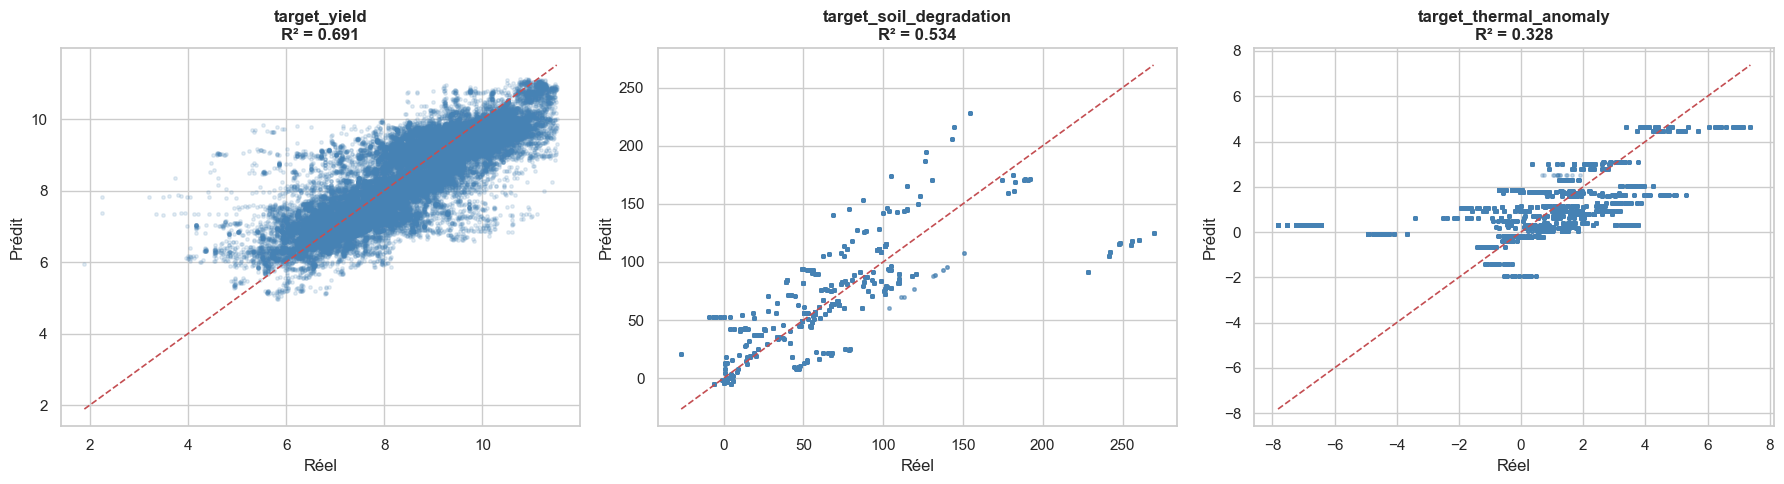

✅ reports/diagnostic_scatter.png


In [8]:
diag = ['target_yield', 'target_soil_degradation', 'target_thermal_anomaly']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, diag):
    pipe = joblib.load(f"models/best_{col}.joblib")
    test = df.loc[test_idx_ml[col]].copy()
    if col == 'target_yield':  # même encodage que l'entraînement (moyennes du train fold)
        for (src, dst), means in yield_enc['maps'].items():
            test[dst] = test[src].map(means).fillna(yield_enc['gmean'])
    feats = [c for c in target_features_map[col] if c in test.columns]
    y_true, y_pred = test[col], pipe.predict(test[feats])
    ax.scatter(y_true, y_pred, alpha=0.15, s=6, c='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.2)
    ax.set_xlabel('Réel'); ax.set_ylabel('Prédit')
    ax.set_title(f"{col}\nR² = {r2_score(y_true, y_pred):.3f}", weight='bold')
plt.tight_layout()
plt.savefig('reports/diagnostic_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ reports/diagnostic_scatter.png")